# Functonal connectivity

In [20]:
# imports 

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import butter, filtfilt

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    RocCurveDisplay
)

from scipy.stats import randint

### 1. Settings

In [21]:
# outputs directories
OUTPUT_DIR = Path("outputs")
FIGURES_DIR = OUTPUT_DIR / "figures"
TABS_DIR = OUTPUT_DIR / "tabs"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABS_DIR.mkdir(parents=True, exist_ok=True)

In [38]:
# EEG frequency 
FREQUENCY_BANDS = {
    "delta": (1, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta": (13, 30)
}

# cerebral regions
REGION_CHANNELS = {
    "frontal": ["Fp1", "Fp2", "F3", "F4", "F7", "F8", "Fz"],
    "central": ["C3", "C4", "Cz"],
    "temporal": ["T7", "T8"],
    "parietal": ["P3", "P4", "P7", "P8", "Pz"],
    "occipital": ["O1", "O2"]
}

# EEG channels
EEG_CHANNELS = [
    "Fp1", "Fp2", "F3", "F4",
    "C3", "C4",
    "P3", "P4",
    "O1", "O2",
    "F7", "F8",
    "T7", "T8",
    "P7", "P8",
    "Fz", "Cz", "Pz"
]

# sampling frequency
SAMPLING_RATE = 128

# Pretty names for plots

FEATURE_LABELS = {
    # Central-parietal
    "central_parietal_delta_connectivity": "Central-Parietal delta",
    "central_parietal_theta_connectivity": "Central-Parietal theta",
    "central_parietal_alpha_connectivity": "Central-Parietal alpha",
    "central_parietal_beta_connectivity": "Central-Parietal beta",

    # Central-occipital
    "central_occipital_delta_connectivity": "Central-Occipital delta",
    "central_occipital_theta_connectivity": "Central-Occipital theta",
    "central_occipital_alpha_connectivity": "Central-Occipital alpha",
    "central_occipital_beta_connectivity": "Central-Occipital beta",

    # Frontal-occipital
    "frontal_occipital_delta_connectivity": "Frontal-Occipital delta",
    "frontal_occipital_theta_connectivity": "Frontal-Occipital theta",
    "frontal_occipital_alpha_connectivity": "Frontal-Occipital alpha",
    "frontal_occipital_beta_connectivity": "Frontal-Occipital beta",

    # Parietal-occipital
    "parietal_occipital_delta_connectivity": "Parietal-Occipital delta",
    "parietal_occipital_theta_connectivity": "Parietal-Occipital theta",
    "parietal_occipital_alpha_connectivity": "Parietal-Occipital alpha",
    "parietal_occipital_beta_connectivity": "Parietal-Occipital beta",

    # Temporal-occipital
    "temporal_occipital_delta_connectivity": "Temporal-Occipital delta",
    "temporal_occipital_theta_connectivity": "Temporal-Occipital theta",
    "temporal_occipital_alpha_connectivity": "Temporal-Occipital alpha",
    "temporal_occipital_beta_connectivity": "Temporal-Occipital beta",

    # Frontal-parietal
    "frontal_parietal_delta_connectivity": "Frontal-Parietal delta",
    "frontal_parietal_theta_connectivity": "Frontal-Parietal theta",
    "frontal_parietal_alpha_connectivity": "Frontal-Parietal alpha",
    "frontal_parietal_beta_connectivity": "Frontal-Parietal beta",

    # Temporal-parietal
    "temporal_parietal_delta_connectivity": "Temporal-Parietal delta",
    "temporal_parietal_theta_connectivity": "Temporal-Parietal theta",
    "temporal_parietal_alpha_connectivity": "Temporal-Parietal alpha",
    "temporal_parietal_beta_connectivity": "Temporal-Parietal beta",

    # Central-temporal
    "central_temporal_delta_connectivity": "Central-Temporal delta",
    "central_temporal_theta_connectivity": "Central-Temporal theta",
    "central_temporal_alpha_connectivity": "Central-Temporal alpha",
    "central_temporal_beta_connectivity": "Central-Temporal beta",

    # Frontal-central
    "frontal_central_delta_connectivity": "Frontal-Central delta",
    "frontal_central_theta_connectivity": "Frontal-Central theta",
    "frontal_central_alpha_connectivity": "Frontal-Central alpha",
    "frontal_central_beta_connectivity": "Frontal-Central beta",

    # Frontal-temporal
    "frontal_temporal_delta_connectivity": "Frontal-Temporal delta",
    "frontal_temporal_theta_connectivity": "Frontal-Temporal theta",
    "frontal_temporal_alpha_connectivity": "Frontal-Temporal alpha",
    "frontal_temporal_beta_connectivity": "Frontal-Temporal beta",
}


In [23]:
# useful functions

def pretty_feature_name(feature):
    """
    Return a readable name for a feature.
    If the feature is not in FEATURE_LABELS, return the original name.
    """
    return FEATURE_LABELS.get(feature, feature) 

# saving functions
def save_table(df, filename, index=False):
    """
    Save a pandas DataFrame inside the outputs/tabs directory.

    Parameters
    ----------
    df : pandas.DataFrame
        Table to save.
    filename : str
        Name of the output CSV file.
    index : bool
        Whether to save the DataFrame index.
    """

    output_path = TABS_DIR / filename
    df.to_csv(output_path, index=index)
    print("Table saved to:", output_path)


def save_figure(filename, dpi=300):
    """
    Save the current matplotlib figure inside the outputs/figures directory.

    Parameters
    ----------
    filename : str
        Name of the output image file.
    dpi : int
        Resolution of the saved figure.
    """

    output_path = FIGURES_DIR / filename
    plt.savefig(output_path, dpi=dpi, bbox_inches="tight")
    print("Figure saved to:", output_path)


# connectivity preprocessing functions
def clean_region_channels(region_channels, available_channels):
    """
    Keep only the channels that are actually present in the dataset.

    Parameters
    ----------
    region_channels : dict
        Dictionary where keys are region names and values are lists of channels.
    available_channels : list
        List of EEG channels available in the dataset.

    Returns
    -------
    cleaned : dict
        Dictionary with the same regions, but only with available channels.
    """

    cleaned = {}

    for region, channels in region_channels.items():
        cleaned[region] = [
            ch for ch in channels
            if ch in available_channels
        ]

    return cleaned


def bandpass_filter(data, sfreq, low_freq, high_freq, order=4):
    """
    Apply a band-pass filter to EEG data.

    The input data must have shape:
        channels x time

    Filtering is applied along the time axis.

    Parameters
    ----------
    data : array-like
        EEG data with shape channels x time.
    sfreq : float
        Sampling frequency in Hz.
    low_freq : float
        Lower cutoff frequency.
    high_freq : float
        Upper cutoff frequency.
    order : int
        Filter order.

    Returns
    -------
    filtered_data : array-like
        Band-pass filtered EEG data.
    """

    nyquist = sfreq / 2

    low = low_freq / nyquist
    high = high_freq / nyquist

    b, a = butter(
        order,
        [low, high],
        btype="bandpass"
    )

    filtered_data = filtfilt(
        b,
        a,
        data,
        axis=1
    )

    return filtered_data


# connectivity feature extraction functions
def compute_channel_connectivity_features(
    eeg_data,
    channel_names,
    sfreq,
    frequency_bands,
    method="pearson"
):
    """
    Compute channel-level functional connectivity features for one subject.

    For each frequency band:
    1. the EEG signal is band-pass filtered;
    2. a correlation matrix is computed between EEG channels;
    3. the upper triangular part of the matrix is extracted as features.

    Each feature represents the connectivity between two EEG channels
    in a specific frequency band.

    Example feature name:
        F3_C3_theta_connectivity

    Parameters
    ----------
    eeg_data : array-like
        EEG data with shape channels x time.
    channel_names : list
        Names of the EEG channels.
    sfreq : float
        Sampling frequency in Hz.
    frequency_bands : dict
        Dictionary of frequency bands.
        Example: {"theta": (4, 8), "beta": (13, 30)}
    method : str
        Correlation method. Usually "pearson" or "spearman".

    Returns
    -------
    features : dict
        Dictionary containing channel-level connectivity features.
    """

    features = {}

    for band_name, (low_freq, high_freq) in frequency_bands.items():

        filtered_data = bandpass_filter(
            data=eeg_data,
            sfreq=sfreq,
            low_freq=low_freq,
            high_freq=high_freq
        )

        # pandas expects shape time x channels for correlation.
        corr_matrix = pd.DataFrame(
            filtered_data.T,
            columns=channel_names
        ).corr(method=method)

        # Extract only unique channel pairs.
        for i in range(len(channel_names)):
            for j in range(i + 1, len(channel_names)):

                ch1 = channel_names[i]
                ch2 = channel_names[j]

                feature_name = f"{ch1}_{ch2}_{band_name}_connectivity"
                features[feature_name] = corr_matrix.loc[ch1, ch2]

    return features


def compute_regional_connectivity_features(
    eeg_data,
    channel_names,
    sfreq,
    frequency_bands,
    region_channels,
    method="pearson"
):
    """
    Compute regional functional connectivity features for one subject.

    For each frequency band:
    1. EEG signals are band-pass filtered.
    2. Channels belonging to the same region are averaged.
    3. Connectivity is computed as correlation between regional time series.

    Each pair of regions becomes one feature.

    Example feature name:
        frontal_central_theta_connectivity

    Parameters
    ----------
    eeg_data : array-like
        EEG data with shape channels x time.
    channel_names : list
        Names of the EEG channels.
    sfreq : float
        Sampling frequency in Hz.
    frequency_bands : dict
        Dictionary of frequency bands.
    region_channels : dict
        Dictionary defining which channels belong to each region.
    method : str
        Correlation method used by pandas corr().

    Returns
    -------
    features : dict
        Dictionary containing regional connectivity features.
    """

    features = {}

    channel_to_index = {
        ch: idx for idx, ch in enumerate(channel_names)
    }

    cleaned_region_channels = clean_region_channels(
        region_channels,
        channel_names
    )

    for band_name, (low_freq, high_freq) in frequency_bands.items():

        filtered_data = bandpass_filter(
            data=eeg_data,
            sfreq=sfreq,
            low_freq=low_freq,
            high_freq=high_freq
        )

        regional_signals = {}

        # Average all channels belonging to the same region.
        for region, channels in cleaned_region_channels.items():

            if len(channels) == 0:
                continue

            indices = [
                channel_to_index[ch]
                for ch in channels
            ]

            regional_signals[region] = filtered_data[indices, :].mean(axis=0)

        region_names = list(regional_signals.keys())

        regional_data = pd.DataFrame({
            region: regional_signals[region]
            for region in region_names
        })

        corr_matrix = regional_data.corr(method=method)

        # Keep only unique region pairs.
        for i in range(len(region_names)):
            for j in range(i + 1, len(region_names)):

                region1 = region_names[i]
                region2 = region_names[j]

                feature_name = f"{region1}_{region2}_{band_name}_connectivity"
                features[feature_name] = corr_matrix.loc[region1, region2]

    return features


# cross-validation evaluation
def evaluate_feature_set(feature_set_name, feature_cols):
    """
    Evaluate a Random Forest classifier using cross-validation
    on the training/validation set.

    This function is used before the final test evaluation to compare
    different connectivity feature sets:
        - all connectivity features
        - channel-level connectivity features
        - regional connectivity features

    Important:
    The independent test set is not used here.
    """

    X_train = train_df[feature_cols]

    scoring = [
        "accuracy",
        "balanced_accuracy",
        "f1",
        "roc_auc",
        "precision",
        "recall"
    ]

    cv_results = cross_validate(
        rf_model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=False
    )

    result = {
        "feature_set": feature_set_name,
        "n_features": len(feature_cols),

        "accuracy_mean": cv_results["test_accuracy"].mean(),
        "accuracy_std": cv_results["test_accuracy"].std(),

        "balanced_accuracy_mean": cv_results["test_balanced_accuracy"].mean(),
        "balanced_accuracy_std": cv_results["test_balanced_accuracy"].std(),

        "f1_mean": cv_results["test_f1"].mean(),
        "f1_std": cv_results["test_f1"].std(),

        "roc_auc_mean": cv_results["test_roc_auc"].mean(),
        "roc_auc_std": cv_results["test_roc_auc"].std(),

        "precision_mean": cv_results["test_precision"].mean(),
        "precision_std": cv_results["test_precision"].std(),

        "recall_mean": cv_results["test_recall"].mean(),
        "recall_std": cv_results["test_recall"].std()
    }

    return result


# Random Forest hyperparameter tuning
def randomized_then_local_grid_search(
    X_train,
    y_train,
    model_name,
    n_iter=80,
    random_state=42
):
    """
    Tune a Random Forest classifier in two steps.

    Step 1:
    RandomizedSearchCV explores a wide hyperparameter space.

    Step 2:
    GridSearchCV performs a local search around the best parameters
    found by RandomizedSearchCV.

    The optimization metric is balanced accuracy.
    """

    random_param_dist = {
        "n_estimators": randint(200, 1500),
        "max_depth": [None, 3, 5, 7, 10, 15, 20, 30],
        "min_samples_leaf": randint(1, 10),
        "min_samples_split": randint(2, 15),
        "max_features": ["sqrt", "log2", None]
    }

    base_rf_model = RandomForestClassifier(
        random_state=random_state,
        class_weight="balanced"
    )

    random_search = RandomizedSearchCV(
        estimator=base_rf_model,
        param_distributions=random_param_dist,
        n_iter=n_iter,
        scoring="balanced_accuracy",
        cv=cv,
        n_jobs=-1,
        random_state=random_state,
        return_train_score=True
    )

    random_search.fit(X_train, y_train)

    print(f"\n{model_name}")
    print("Best parameters from RandomizedSearchCV:")
    print(random_search.best_params_)
    print("Best randomized-search CV balanced accuracy:")
    print(random_search.best_score_)

    random_search_results_df = pd.DataFrame(
        random_search.cv_results_
    ).sort_values("rank_test_score")

    save_table(
        random_search_results_df,
        f"3b_rf_{model_name}_randomized_search_results.csv"
    )

    random_best_params_df = pd.DataFrame([random_search.best_params_])
    random_best_params_df["best_randomized_cv_balanced_accuracy"] = random_search.best_score_

    save_table(
        random_best_params_df,
        f"3b_rf_{model_name}_randomized_search_best_params.csv"
    )

    best_random_params = random_search.best_params_

    best_n_estimators = best_random_params["n_estimators"]
    best_max_depth = best_random_params["max_depth"]
    best_min_samples_leaf = best_random_params["min_samples_leaf"]
    best_min_samples_split = best_random_params["min_samples_split"]
    best_max_features = best_random_params["max_features"]

    def make_int_grid(center, step, min_value):
        values = [
            max(min_value, center - step),
            center,
            center + step
        ]

        return sorted(list(set(values)))

    if best_max_depth is None:
        local_max_depth_values = [None, 5, 10, 15, 20, 30]
    else:
        local_max_depth_values = sorted(
            list(set([
                None,
                max(1, best_max_depth - 5),
                best_max_depth,
                best_max_depth + 5
            ])),
            key=lambda x: 999 if x is None else x
        )

    local_param_grid = {
        "n_estimators": make_int_grid(
            center=best_n_estimators,
            step=200,
            min_value=100
        ),
        "max_depth": local_max_depth_values,
        "min_samples_leaf": make_int_grid(
            center=best_min_samples_leaf,
            step=1,
            min_value=1
        ),
        "min_samples_split": make_int_grid(
            center=best_min_samples_split,
            step=2,
            min_value=2
        ),
        "max_features": list(dict.fromkeys([
            best_max_features,
            "sqrt",
            "log2",
            None
        ]))
    }

    print("\nLocal parameter grid:")
    display(local_param_grid)

    local_grid_search = GridSearchCV(
        estimator=base_rf_model,
        param_grid=local_param_grid,
        scoring="balanced_accuracy",
        cv=cv,
        n_jobs=-1,
        return_train_score=True
    )

    local_grid_search.fit(X_train, y_train)

    print("Best parameters after local GridSearchCV:")
    print(local_grid_search.best_params_)
    print("Best local grid-search CV balanced accuracy:")
    print(local_grid_search.best_score_)

    local_grid_results_df = pd.DataFrame(
        local_grid_search.cv_results_
    ).sort_values("rank_test_score")

    save_table(
        local_grid_results_df,
        f"3b_rf_{model_name}_local_grid_search_results.csv"
    )

    local_grid_best_params_df = pd.DataFrame([local_grid_search.best_params_])
    local_grid_best_params_df["best_local_grid_cv_balanced_accuracy"] = local_grid_search.best_score_

    save_table(
        local_grid_best_params_df,
        f"3b_rf_{model_name}_local_grid_search_best_params.csv"
    )

    display(local_grid_best_params_df)

    return local_grid_search


# Logistic Regression hyperparameter tuning
def tune_logistic_regression(
    X_train,
    y_train,
    model_name
):
    """
    Tune Logistic Regression using cross-validation on the training set.

    A StandardScaler is included inside the pipeline to avoid data leakage.
    This is important because Logistic Regression is sensitive to the scale
    of the input features.

    The optimization metric is balanced accuracy.
    """

    logreg_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            random_state=42
        ))
    ])

    param_grid = {
        "classifier__C": [0.001, 0.01, 0.1, 1, 10, 100],
        "classifier__penalty": ["l2"],
        "classifier__solver": ["lbfgs"]
    }

    grid_search = GridSearchCV(
        estimator=logreg_pipeline,
        param_grid=param_grid,
        scoring="balanced_accuracy",
        cv=cv,
        n_jobs=-1,
        return_train_score=True
    )

    grid_search.fit(X_train, y_train)

    print(f"\n{model_name}")
    print("Best Logistic Regression parameters:")
    print(grid_search.best_params_)
    print("Best CV balanced accuracy:")
    print(grid_search.best_score_)

    results_df = pd.DataFrame(
        grid_search.cv_results_
    ).sort_values("rank_test_score")

    save_table(
        results_df,
        f"3b_logreg_{model_name}_grid_search_results.csv"
    )

    best_params_df = pd.DataFrame([grid_search.best_params_])
    best_params_df["best_cv_balanced_accuracy"] = grid_search.best_score_

    save_table(
        best_params_df,
        f"3b_logreg_{model_name}_best_params.csv"
    )

    display(best_params_df)

    return grid_search


# Final test-set evaluation
def evaluate_final_model_on_test_set(
    fitted_model,
    X_train,
    y_train,
    X_test,
    y_test,
    feature_set_name,
    n_features,
    output_prefix,
    extra_info=None
):
    """
    Train the selected model on the full training set
    and evaluate it once on the independent test set.

    This function is used after cross-validation and hyperparameter tuning.
    It saves:
        - final test metrics
        - ROC curve
        - confusion matrix
        - classification report
    """

    fitted_model.fit(X_train, y_train)

    y_test_pred = fitted_model.predict(X_test)
    y_test_proba = fitted_model.predict_proba(X_test)[:, 1]

    final_results = {
        "feature_set": feature_set_name,
        "n_features": n_features,
        "accuracy": accuracy_score(y_test, y_test_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_test_pred),
        "precision": precision_score(y_test, y_test_pred),
        "recall": recall_score(y_test, y_test_pred),
        "f1": f1_score(y_test, y_test_pred),
        "roc_auc": roc_auc_score(y_test, y_test_proba)
    }

    if extra_info is not None:
        final_results.update(extra_info)

    final_results_df = pd.DataFrame([final_results])

    save_table(
        final_results_df,
        f"{output_prefix}_test_metrics.csv"
    )

    display(final_results_df)

    # ROC curve
    plt.figure(figsize=(6, 6))

    RocCurveDisplay.from_predictions(
        y_test,
        y_test_proba,
        name=feature_set_name
    )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        color="black",
        linewidth=1,
        label="Chance"
    )

    plt.title(f"ROC curve on final test set\n{feature_set_name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.grid(linestyle="--", alpha=0.4)

    plt.tight_layout()

    save_figure(
        f"{output_prefix}_roc_curve.png"
    )

    plt.show()

    # Confusion matrix
    cm = confusion_matrix(
        y_test,
        y_test_pred,
        labels=[0, 1]
    )

    cm_df = pd.DataFrame(
        cm,
        index=["True Control", "True ADHD"],
        columns=["Predicted Control", "Predicted ADHD"]
    )

    save_table(
        cm_df,
        f"{output_prefix}_confusion_matrix.csv",
        index=True
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Control", "ADHD"]
    )

    disp.plot(cmap="Greens")

    plt.title(f"Final test confusion matrix\n{feature_set_name}")

    plt.tight_layout()

    save_figure(
        f"{output_prefix}_confusion_matrix.png"
    )

    plt.show()

    display(cm_df)

    # Classification report
    report_dict = classification_report(
        y_test,
        y_test_pred,
        target_names=["Control", "ADHD"],
        output_dict=True
    )

    report_df = pd.DataFrame(report_dict).T

    save_table(
        report_df,
        f"{output_prefix}_classification_report.csv",
        index=True
    )

    display(report_df)

    return final_results_df, fitted_model, y_test_pred, y_test_proba

### 2. Dataset

In [24]:
# dataset location
DATA_DIR = Path("data")
CSV_NAME = "adhdata.csv"
CSV_PATH = DATA_DIR / CSV_NAME

# data type 
dtype_map = {ch: "float32" for ch in EEG_CHANNELS}
dtype_map.update({
    "Class": "category",
    "ID": "category"
})

# load dataset
df = pd.read_csv(
    CSV_PATH,
    dtype=dtype_map
)

# shape
print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (2166383, 21)


,Fp1,Fp2,F3,F4,C3,C4,P3,P4,O1,O2,...,F8,T7,T8,P7,P8,Fz,Cz,Pz,Class,ID
0,261.0,402.0,16.0,261.0,126.0,384.0,126.0,236.0,52.0,236.0,...,16.0,200.0,494.0,126.0,236.0,121.0,367.0,121.0,ADHD,v10p
1,121.0,191.0,-94.0,85.0,16.0,200.0,126.0,52.0,347.0,273.0,...,-57.0,126.0,347.0,52.0,52.0,15.0,121.0,-19.0,ADHD,v10p
2,-55.0,85.0,-204.0,15.0,-57.0,200.0,52.0,126.0,236.0,200.0,...,-94.0,126.0,420.0,52.0,126.0,-55.0,261.0,85.0,ADHD,v10p
3,191.0,85.0,52.0,50.0,89.0,236.0,163.0,89.0,89.0,89.0,...,-57.0,236.0,420.0,126.0,126.0,15.0,85.0,-55.0,ADHD,v10p
4,-55.0,-125.0,-204.0,-160.0,-204.0,16.0,-241.0,-241.0,89.0,16.0,...,-131.0,89.0,310.0,-57.0,52.0,-55.0,15.0,-336.0,ADHD,v10p


In [25]:
subjects = []

# group dataframe by subject ID
for subject_id, subject_df in df.groupby("ID", observed=True):

    # class label(Control / ADHD)
    class_label = subject_df["Class"].iloc[0]

    # EEG samples to a numpy array
    # shape: channels x time
    eeg_data = subject_df[EEG_CHANNELS].to_numpy().T

    # storage subject information in a dictionary
    subject = {
        "ID": subject_id,
        "Class": class_label,
        "data": eeg_data,
        "channel_names": EEG_CHANNELS,
        "sfreq": SAMPLING_RATE
    }

    subjects.append(subject)

# display summary
print("Number of subjects:", len(subjects))

print("Example subject keys:")
print(subjects[0].keys())

print("Example EEG data shape:")
print(subjects[0]["data"].shape)

print("Example class:")
print(subjects[0]["Class"])

Number of subjects: 121
Example subject keys:
dict_keys(['ID', 'Class', 'data', 'channel_names', 'sfreq'])
Example EEG data shape:
(19, 14304)
Example class:
ADHD


In [26]:
connectivity_rows = []

# process each subject
for subject in subjects:

    # extract subject information
    eeg_data = subject["data"]
    channel_names = subject["channel_names"]
    sfreq = subject["sfreq"]
    subject_id = subject["ID"]
    class_label = subject["Class"]

    # compute channel-level functional connectivity features
    channel_features = compute_channel_connectivity_features(
        eeg_data=eeg_data,
        channel_names=channel_names,
        sfreq=sfreq,
        frequency_bands=FREQUENCY_BANDS,
        method="pearson"
    )

    # compute region-level functional connectivity features
    regional_features = compute_regional_connectivity_features(
        eeg_data=eeg_data,
        channel_names=channel_names,
        sfreq=sfreq,
        frequency_bands=FREQUENCY_BANDS,
        region_channels=REGION_CHANNELS,
        method="pearson"
    )

    # create a single feature vector for the current subject
    row = {
        "ID": subject_id,
        "Class": class_label
    }

    # add channel-level and regional-level connectivity features
    row.update(channel_features)
    row.update(regional_features)

    connectivity_rows.append(row)

# convert the extracted features into a DataFrame
connectivity_features_df = pd.DataFrame(connectivity_rows)

# save the feature matrix
connectivity_features_df.to_csv(
    TABS_DIR / "3b_connectivity_features_data.csv",
    index=False
)

# preview
display(connectivity_features_df.head())

,ID,Class,Fp1_Fp2_delta_connectivity,Fp1_F3_delta_connectivity,Fp1_F4_delta_connectivity,Fp1_C3_delta_connectivity,Fp1_C4_delta_connectivity,Fp1_P3_delta_connectivity,Fp1_P4_delta_connectivity,Fp1_O1_delta_connectivity,...,frontal_central_beta_connectivity,frontal_temporal_beta_connectivity,frontal_parietal_beta_connectivity,frontal_occipital_beta_connectivity,central_temporal_beta_connectivity,central_parietal_beta_connectivity,central_occipital_beta_connectivity,temporal_parietal_beta_connectivity,temporal_occipital_beta_connectivity,parietal_occipital_beta_connectivity
0,v10p,ADHD,0.918109,0.590839,0.541248,0.365946,0.407166,0.263526,0.229854,0.214890,...,0.369430,0.309126,0.074637,-0.018761,0.648872,0.685902,0.365627,0.595145,0.285800,0.706176
1,v12p,ADHD,0.758434,0.545504,0.449498,0.437778,0.294654,0.166463,0.155327,0.025878,...,0.464643,0.355805,0.008779,-0.140973,0.542295,0.468375,0.117834,0.404690,0.085963,0.605554
2,v14p,ADHD,0.911363,0.526202,0.513500,0.287672,0.377434,0.094479,0.194675,-0.053323,...,0.460945,0.268075,0.045896,-0.037859,0.547406,0.417497,0.234500,0.549012,0.303874,0.815252
3,v15p,ADHD,0.741492,0.784980,0.518415,0.634565,-0.003422,0.587215,0.192234,0.637046,...,0.535205,0.206688,0.067553,0.231378,0.315237,0.382113,0.441594,0.451454,0.239156,0.581271
4,v173,ADHD,0.552951,0.684051,0.685040,0.355759,0.276624,0.068992,-0.078552,-0.043291,...,0.498138,0.416615,0.235988,0.134656,0.563668,0.518866,0.411411,0.434004,0.293522,0.797992


In [27]:
# columns that identify the subject and the diagnostic group
metadata_cols = [
    "ID",
    "Class"
]

# select all connectivity features
all_connectivity_cols = [
    c for c in connectivity_features_df.columns
    if c not in metadata_cols
]

# select regional connectivty features
# identified by their region-based prefixes
regional_connectivity_cols = [
    c for c in all_connectivity_cols
    if (
        c.startswith("frontal_")
        or c.startswith("central_")
        or c.startswith("temporal_")
        or c.startswith("parietal_")
        or c.startswith("occipital_")
    )
]

# select channel-level connectivity features
channel_connectivity_cols = [
    c for c in all_connectivity_cols
    if c not in regional_connectivity_cols
]

print("All connectivity features:", len(all_connectivity_cols))
print("Channel connectivity features:", len(channel_connectivity_cols))
print("Regional connectivity features:", len(regional_connectivity_cols))

All connectivity features: 724
Channel connectivity features: 684
Regional connectivity features: 40


### 3. Random Forest

In [28]:
# split into training and test set
train_df, test_df = train_test_split(
    connectivity_features_df,
    test_size=0.20,
    stratify=connectivity_features_df["Class"], # stratification preserves the proportion of Control and ADHD subjects
    random_state=42
)

# convert class labels into binary numerical labels:
# Control = 0, ADHD = 1
y_train = train_df["Class"].map({
    "Control": 0,
    "ADHD": 1
})

y_test = test_df["Class"].map({
    "Control": 0,
    "ADHD": 1
})

In [29]:
# stratified 5-fold cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Define the Random Forest classifier
# class_weight="balanced" compensates for possible class imbalance
rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    class_weight="balanced"
)

In [30]:
connectivity_results = []

# evaluate the model using all connectivity features
connectivity_results.append(
    evaluate_feature_set(
        "All connectivity features",
        all_connectivity_cols
    )
)

# evaluate the model using all connectivity features
connectivity_results.append(
    evaluate_feature_set(
        "Channel-level connectivity features",
        channel_connectivity_cols
    )
)

# evaluate the model using only regional connectivity features
connectivity_results.append(
    evaluate_feature_set(
        "Regional connectivity features",
        regional_connectivity_cols
    )
)

# convert the evaluation results into a DataFrame
connectivity_results_df = pd.DataFrame(connectivity_results)

# save the comparison table
connectivity_results_df.to_csv(
    TABS_DIR / "3b_rf_connectivity_feature_set_comparison.csv",
    index=False
)

display(connectivity_results_df)

,feature_set,n_features,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,precision_mean,precision_std,recall_mean,recall_std
0,All connectivity features,724,0.688421,0.089715,0.684444,0.086167,0.703333,0.106898,0.720667,0.074368,0.661075,0.079312,0.768889,0.175175
1,Channel-level connectivity features,684,0.708947,0.075607,0.705556,0.073367,0.730877,0.071567,0.722444,0.073938,0.692033,0.098341,0.791111,0.110084
2,Regional connectivity features,40,0.710000,0.133775,0.707778,0.132339,0.718272,0.152658,0.768889,0.115556,0.685653,0.123890,0.773333,0.202405


In [31]:
# sort feature sets by mean balanced accuracy and select the best one
best_connectivity_row = connectivity_results_df.sort_values(
    "balanced_accuracy_mean",
    ascending=False
).iloc[0]

# name of the best-performing feature set
best_connectivity_feature_set_name = best_connectivity_row["feature_set"]

# assign the corresponding list of feature columns
if best_connectivity_feature_set_name == "All connectivity features":
    best_connectivity_feature_cols = all_connectivity_cols

elif best_connectivity_feature_set_name == "Channel-level connectivity features":
    best_connectivity_feature_cols = channel_connectivity_cols

elif best_connectivity_feature_set_name == "Regional connectivity features":
    best_connectivity_feature_cols = regional_connectivity_cols

print("Best connectivity feature set:")
print(best_connectivity_feature_set_name)

print("Number of features:")
print(len(best_connectivity_feature_cols))

Best connectivity feature set:
Regional connectivity features
Number of features:
40


In [32]:
# training and test matrices using the selected connectivity features
X_train_connectivity = train_df[best_connectivity_feature_cols]
X_test_connectivity = test_df[best_connectivity_feature_cols]

In [33]:
# tune Random Forest hyperparameters on the training set
# first randomized search and then local grid around the best configuration
connectivity_grid_search = randomized_then_local_grid_search(
    X_train=X_train_connectivity,
    y_train=y_train,
    model_name="connectivity_best_feature_set",
    n_iter=80,
    random_state=42
)


connectivity_best_feature_set
Best parameters from RandomizedSearchCV:
{'max_depth': 20, 'max_features': 'log2', 'min_samples_leaf': 3, 'min_samples_split': 8, 'n_estimators': 530}
Best randomized-search CV balanced accuracy:
0.7077777777777776
Table saved to: outputs\tabs\3b_rf_connectivity_best_feature_set_randomized_search_results.csv
Table saved to: outputs\tabs\3b_rf_connectivity_best_feature_set_randomized_search_best_params.csv

Local parameter grid:


{'n_estimators': [330, 530, 730],
 'max_depth': [15, 20, 25, None],
 'min_samples_leaf': [2, 3, 4],
 'min_samples_split': [6, 8, 10],
 'max_features': ['log2', 'sqrt', None]}

c:\Users\noemi\anaconda3\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best parameters after local GridSearchCV:
{'max_depth': 15, 'max_features': 'log2', 'min_samples_leaf': 3, 'min_samples_split': 10, 'n_estimators': 330}
Best local grid-search CV balanced accuracy:
0.7188888888888888
Table saved to: outputs\tabs\3b_rf_connectivity_best_feature_set_local_grid_search_results.csv
Table saved to: outputs\tabs\3b_rf_connectivity_best_feature_set_local_grid_search_best_params.csv


,max_depth,max_features,min_samples_leaf,min_samples_split,n_estimators,best_local_grid_cv_balanced_accuracy
0,15,log2,3,10,330,0.718889


Table saved to: outputs\tabs\3b_rf_connectivity_best_feature_set_test_metrics.csv


,feature_set,n_features,accuracy,balanced_accuracy,precision,recall,f1,roc_auc
0,Regional connectivity features,40,0.92,0.919872,0.923077,0.923077,0.923077,0.929487


Figure saved to: outputs\figures\3b_rf_connectivity_best_feature_set_roc_curve.png


<Figure size 600x600 with 0 Axes>

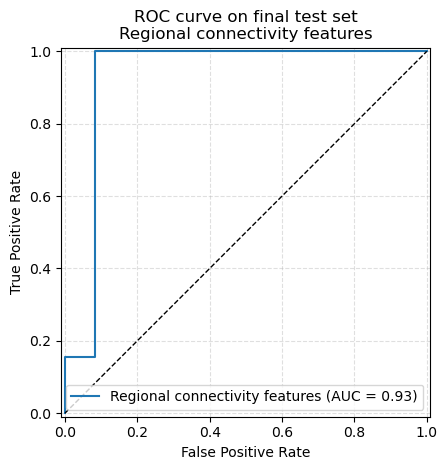

Table saved to: outputs\tabs\3b_rf_connectivity_best_feature_set_confusion_matrix.csv
Figure saved to: outputs\figures\3b_rf_connectivity_best_feature_set_confusion_matrix.png


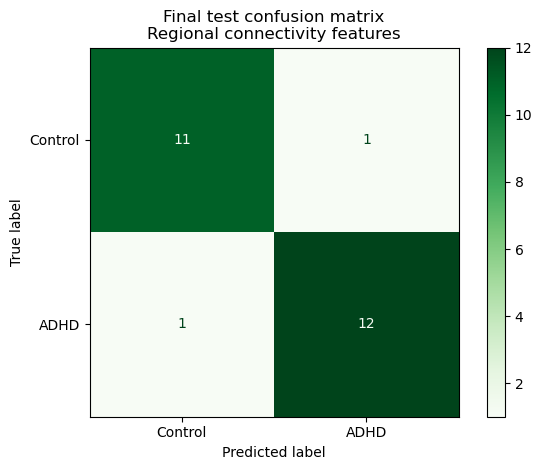

,Predicted Control,Predicted ADHD
True Control,11,1
True ADHD,1,12


Table saved to: outputs\tabs\3b_rf_connectivity_best_feature_set_classification_report.csv


,precision,recall,f1-score,support
Control,0.916667,0.916667,0.916667,12.00
ADHD,0.923077,0.923077,0.923077,13.00
accuracy,0.920000,0.920000,0.920000,0.92
macro avg,0.919872,0.919872,0.919872,25.00
weighted avg,0.920000,0.920000,0.920000,25.00


In [34]:
# evaluate the best tuned model on the test set
connectivity_test_results_df, connectivity_rf_model, y_test_connectivity_pred, y_test_connectivity_proba = evaluate_final_model_on_test_set(
    fitted_model=connectivity_grid_search.best_estimator_,
    X_train=X_train_connectivity,
    y_train=y_train,
    X_test=X_test_connectivity,
    y_test=y_test,
    feature_set_name=best_connectivity_feature_set_name,
    n_features=len(best_connectivity_feature_cols),
    output_prefix="3b_rf_connectivity_best_feature_set"
)

In [35]:
# Feature importance for Random Forest functional connectivity model

connectivity_feature_importance_df = pd.DataFrame({
    "feature": best_connectivity_feature_cols,
    "importance": connectivity_rf_model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

save_table(
    connectivity_feature_importance_df,
    "3b_rf_connectivity_feature_importance.csv"
)

display(connectivity_feature_importance_df.head(15))

Table saved to: outputs\tabs\3b_rf_connectivity_feature_importance.csv


,feature,importance
35,central_parietal_beta_connectivity,0.084487
25,central_parietal_alpha_connectivity,0.081593
36,central_occipital_beta_connectivity,0.076649
33,frontal_occipital_beta_connectivity,0.041283
15,central_parietal_theta_connectivity,0.039112
3,frontal_occipital_delta_connectivity,0.036301
39,parietal_occipital_beta_connectivity,0.035135
26,central_occipital_alpha_connectivity,0.034366
16,central_occipital_theta_connectivity,0.030072
38,temporal_occipital_beta_connectivity,0.029043


C:\Users\noemi\AppData\Local\Temp\ipykernel_568\4012076002.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_importance["pretty_feature"] = top_importance["feature"].apply(


Figure saved to: outputs\figures\3b_rf_connectivity_feature_importance_top15.png


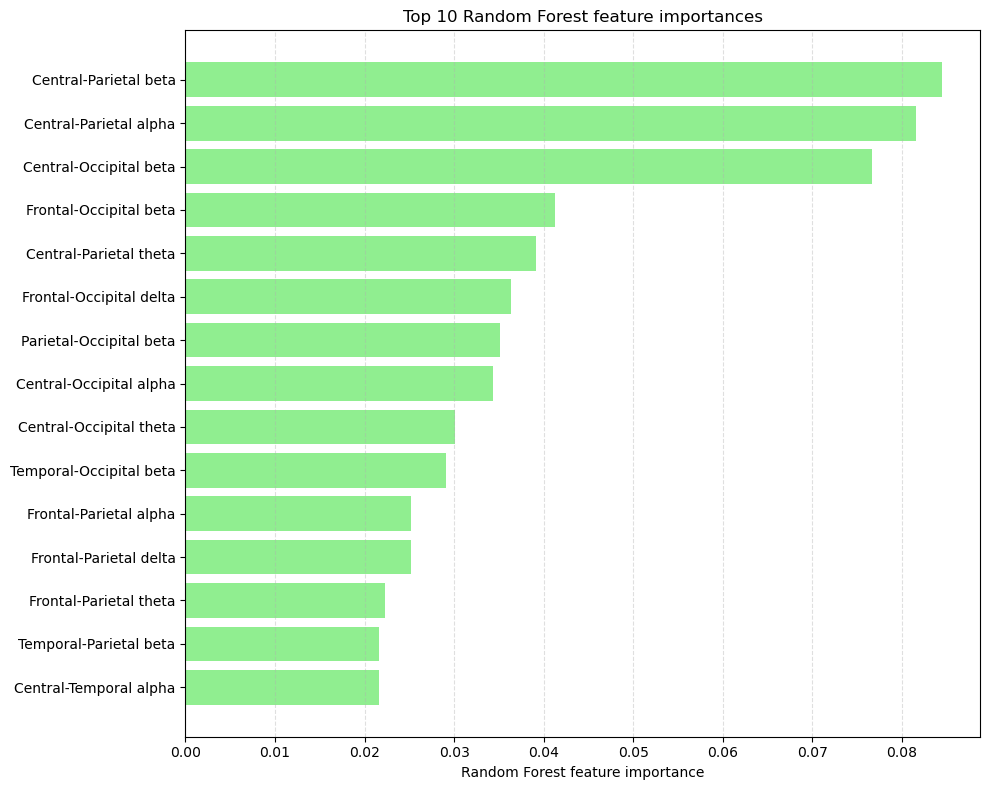

In [39]:
# Plot top functional connectivity features

top_importance = connectivity_feature_importance_df.head(15)

top_importance["pretty_feature"] = top_importance["feature"].apply(
    pretty_feature_name
)

plt.figure(figsize=(10, 8))

plt.xticks(np.arange(0, 0.1, 0.01))

plt.barh(
    top_importance["pretty_feature"],
    top_importance["importance"],
    color = 'lightgreen'
)

plt.xlabel("Random Forest feature importance")
plt.title(
    f"Top 10 Random Forest feature importances"
)

plt.gca().invert_yaxis()

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
save_figure("3b_rf_connectivity_feature_importance_top15.png")
plt.show()

### 4. Logistic Regression


connectivity_best_feature_set
Best Logistic Regression parameters:
{'classifier__C': 0.1, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}
Best CV balanced accuracy:
0.6755555555555557
Table saved to: outputs\tabs\3b_logreg_connectivity_best_feature_set_grid_search_results.csv
Table saved to: outputs\tabs\3b_logreg_connectivity_best_feature_set_best_params.csv


,classifier__C,classifier__penalty,classifier__solver,best_cv_balanced_accuracy
0,0.1,l2,lbfgs,0.675556


Table saved to: outputs\tabs\3b_logreg_connectivity_best_feature_set_test_metrics.csv


,feature_set,n_features,accuracy,balanced_accuracy,precision,recall,f1,roc_auc
0,Logistic Regression - Regional connectivity fe...,40,0.96,0.958333,0.928571,1.0,0.962963,0.923077


Figure saved to: outputs\figures\3b_logreg_connectivity_best_feature_set_roc_curve.png


<Figure size 600x600 with 0 Axes>

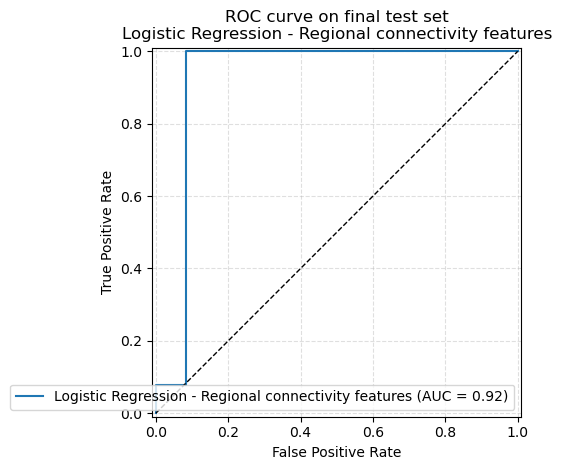

Table saved to: outputs\tabs\3b_logreg_connectivity_best_feature_set_confusion_matrix.csv
Figure saved to: outputs\figures\3b_logreg_connectivity_best_feature_set_confusion_matrix.png


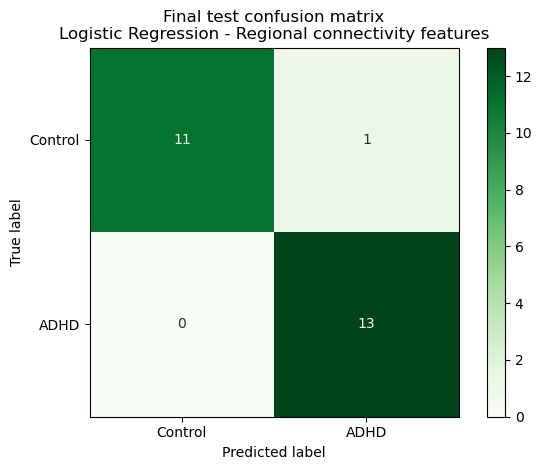

,Predicted Control,Predicted ADHD
True Control,11,1
True ADHD,0,13


Table saved to: outputs\tabs\3b_logreg_connectivity_best_feature_set_classification_report.csv


,precision,recall,f1-score,support
Control,1.000000,0.916667,0.956522,12.00
ADHD,0.928571,1.000000,0.962963,13.00
accuracy,0.960000,0.960000,0.960000,0.96
macro avg,0.964286,0.958333,0.959742,25.00
weighted avg,0.962857,0.960000,0.959871,25.00


In [40]:
# tune Logistic Regression hyperparameters using cross-validation
logreg_connectivity_grid_search = tune_logistic_regression(
    X_train=X_train_connectivity,
    y_train=y_train,
    model_name="connectivity_best_feature_set"
)

# evaluate the best Logistic Regression model on the test set
logreg_connectivity_test_results_df, logreg_connectivity_model, y_test_logreg_connectivity_pred, y_test_logreg_connectivity_proba = evaluate_final_model_on_test_set(
    fitted_model=logreg_connectivity_grid_search.best_estimator_,
    X_train=X_train_connectivity,
    y_train=y_train,
    X_test=X_test_connectivity,
    y_test=y_test,
    feature_set_name=f"Logistic Regression - {best_connectivity_feature_set_name}",
    n_features=len(best_connectivity_feature_cols),
    output_prefix="3b_logreg_connectivity_best_feature_set"
)